# Dragonfly Vision Explorer

This notebook is for figuring out whether the fly can detect the dragonfly from vision before impact. It deliberately looks beyond a single red-hue score: per-eye asymmetry, largest red blob size, blob position, and temporal growth/looming are logged together.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tuftelike
import imageio.v2 as imageio

from IPython.display import HTML, display

from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

## Configuration

Use level 4 for dragonfly trials. This notebook now runs the real `submission.controller.Controller`, so the fly should navigate toward the banana while the dragonfly vision features are logged. `manual_drive` is kept only for optional control experiments; leave it as `None` for normal controller behavior.


In [2]:
level = 4
seed = 1
max_steps = 40_000
log_every = 20
snapshot_limit = 20
video_every = 250
video_path = "dragonfly_vision_explorer.mp4"

# Leave as None to use submission.controller.Controller.
# Set to an array like np.array([0.5, 0.5]) only for fixed-drive control experiments.
manual_drive = None

# Red detector parameters to sweep later.
r_min = 90
dominance = 1.25
red_minus_green_min = 60
hsv_sat_min = 80
hsv_val_min = 70

## Helper Functions

The main object is `extract_dragonfly_features(raw_vision)`. It returns features that can be plotted over time:

- `red_score`: total fraction of red pixels
- `left_score`, `right_score`: per-eye red scores
- `side_bias`: right minus left, normalized
- `largest_blob_frac`: largest connected red component area
- `blob_x`, `blob_y`: largest red blob center in normalized panel coordinates
- `component_count`: number of red connected components

The important experiment is whether `largest_blob_frac` and its temporal growth are more reliable than red fraction alone.

In [3]:
def to_uint8_rgb(img):
    img = np.asarray(img)
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
    return img


def stack_raw_vision(raw_vision):
    eyes = [to_uint8_rgb(eye) for eye in raw_vision]
    return np.concatenate(eyes, axis=1)


def red_masks_from_rgb(
    img_rgb,
    r_min=90,
    dominance=1.25,
    red_minus_green_min=20,
    hsv_sat_min=60,
    hsv_val_min=50,
):
    img = to_uint8_rgb(img_rgb)
    rgb = img.astype(np.float32)
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]

    dominance_mask = (
        (r > r_min)
        & (r > dominance * g)
        & (r > dominance * b)
        & ((r - g) > red_minus_green_min)
    )

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hue = hsv[..., 0]
    sat = hsv[..., 1]
    val = hsv[..., 2]
    hsv_red_mask = ((hue <= 10) | (hue >= 170)) & (sat >= hsv_sat_min) & (val >= hsv_val_min)

    # Keep both masks separately, and use their union for shape/position features.
    combined_mask = dominance_mask | hsv_red_mask
    return dominance_mask, hsv_red_mask, combined_mask


def connected_component_features(mask):
    mask_u8 = np.ascontiguousarray(mask.astype(np.uint8))
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    h, w = mask.shape[:2]

    if n_labels <= 1:
        return {
            'component_count': 0,
            'largest_blob_frac': 0.0,
            'blob_x': np.nan,
            'blob_y': np.nan,
            'blob_width_frac': 0.0,
            'blob_height_frac': 0.0,
        }

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_local = int(np.argmax(areas))
    label_id = largest_local + 1
    area = float(stats[label_id, cv2.CC_STAT_AREA])
    x = float(stats[label_id, cv2.CC_STAT_LEFT])
    y = float(stats[label_id, cv2.CC_STAT_TOP])
    bw = float(stats[label_id, cv2.CC_STAT_WIDTH])
    bh = float(stats[label_id, cv2.CC_STAT_HEIGHT])
    cx, cy = centroids[label_id]

    return {
        'component_count': int(n_labels - 1),
        'largest_blob_frac': area / float(h * w),
        'blob_x': float(cx) / w,
        'blob_y': float(cy) / h,
        'blob_width_frac': bw / w,
        'blob_height_frac': bh / h,
    }


def extract_dragonfly_features(raw_vision):
    raw_panel = stack_raw_vision(raw_vision)
    dominance_mask, hsv_mask, combined_mask = red_masks_from_rgb(
        raw_panel,
        r_min=r_min,
        dominance=dominance,
        red_minus_green_min=red_minus_green_min,
        hsv_sat_min=hsv_sat_min,
        hsv_val_min=hsv_val_min,
    )

    eye_masks = []
    eye_scores = []
    for eye in raw_vision[:2]:
        _, _, eye_mask = red_masks_from_rgb(
            eye,
            r_min=r_min,
            dominance=dominance,
            red_minus_green_min=red_minus_green_min,
            hsv_sat_min=hsv_sat_min,
            hsv_val_min=hsv_val_min,
        )
        eye_masks.append(eye_mask)
        eye_scores.append(float(eye_mask.mean()))

    if len(eye_scores) < 2:
        left_score = right_score = float(combined_mask.mean())
    else:
        left_score, right_score = eye_scores[:2]

    score_sum = left_score + right_score
    side_bias = 0.0 if score_sum == 0 else (right_score - left_score) / score_sum

    features = {
        'red_score': float(combined_mask.mean()),
        'dominance_score': float(dominance_mask.mean()),
        'hsv_red_score': float(hsv_mask.mean()),
        'left_score': float(left_score),
        'right_score': float(right_score),
        'side_bias': float(side_bias),
    }
    features.update(connected_component_features(combined_mask))

    return features, raw_panel, combined_mask


def mask_overlay(raw_panel, mask):
    raw_panel = to_uint8_rgb(raw_panel)
    overlay = raw_panel.copy()
    overlay[mask] = np.array([255, 0, 0], dtype=np.uint8)
    return overlay


def get_world_frame(sim):
    sim.render_as_needed()
    if len(sim.renderer.frames) == 0:
        raise RuntimeError('No rendered frames available yet.')
    world = np.concatenate(
        [frames[-1] for frames in sim.renderer.frames.values() if len(frames) > 0],
        axis=-2,
    )
    return to_uint8_rgb(world)


def resize_width(img, width=700):
    h, w = img.shape[:2]
    scale = width / w
    return cv2.resize(img, (width, int(h * scale)), interpolation=cv2.INTER_NEAREST)


def make_debug_panel(world, raw_panel, mask):
    world_r = resize_width(to_uint8_rgb(world), width=700)
    raw_r = resize_width(to_uint8_rgb(raw_panel), width=700)
    overlay_r = resize_width(mask_overlay(raw_panel, mask), width=700)
    return np.vstack([world_r, raw_r, overlay_r])


def records_to_arrays(records):
    """Convert feature records to numpy arrays for plotting during and after a run."""
    if len(records) == 0:
        return {
            'steps': np.array([]),
            'red_scores': np.array([]),
            'hsv_scores': np.array([]),
            'largest_blob': np.array([]),
            'looming': np.array([]),
            'side_bias': np.array([]),
        }

    steps = np.array([r['step'] for r in records])
    red_scores = np.array([r['red_score'] for r in records])
    hsv_scores = np.array([r['hsv_red_score'] for r in records])
    largest_blob = np.array([r['largest_blob_frac'] for r in records])
    side_bias = np.array([r['side_bias'] for r in records])

    looming = np.zeros_like(largest_blob)
    if len(largest_blob) > 1:
        looming[1:] = np.maximum(0.0, np.diff(largest_blob))

    return {
        'steps': steps,
        'red_scores': red_scores,
        'hsv_scores': hsv_scores,
        'largest_blob': largest_blob,
        'looming': looming,
        'side_bias': side_bias,
    }


def apply_tufte(ax, xs, *ys_series):
    """Apply matplotlib-tufte styling to an axis, using all visible series limits."""
    xs = np.asarray(xs)
    valid_xs = []
    valid_ys = []
    for ys in ys_series:
        ys = np.asarray(ys)
        valid = np.isfinite(xs) & np.isfinite(ys)
        if np.any(valid):
            valid_xs.append(xs[valid])
            valid_ys.append(ys[valid])

    ax.grid(False)
    if not valid_xs:
        return

    plt.sca(ax)
    tuftelike.adjust(np.concatenate(valid_xs), np.concatenate(valid_ys))


def show_live_vision_and_curves(records, panel, latest, snapshot_steps=None):
    """Show the current raw vision next to curves with a current-step marker."""
    arrays = records_to_arrays(records)
    steps = arrays['steps']
    red_scores = arrays['red_scores']
    hsv_scores = arrays['hsv_scores']
    largest_blob = arrays['largest_blob']
    looming = arrays['looming']
    side_bias = arrays['side_bias']

    snapshot_steps = [] if snapshot_steps is None else snapshot_steps

    fig = plt.figure(figsize=(16, 10))
    grid = fig.add_gridspec(3, 2, width_ratios=[1.0, 1.25])

    ax_img = fig.add_subplot(grid[:, 0])
    ax_img.imshow(panel)
    ax_img.set_title(
        f"live step={latest['step']} | red={latest['red_score']:.5f} | "
        f"blob={latest['largest_blob_frac']:.5f} | side={latest['side_bias']:.2f}"
    )
    ax_img.axis('off')

    axes = [fig.add_subplot(grid[i, 1]) for i in range(3)]

    axes[0].plot(steps, red_scores, label='combined red score')
    axes[0].plot(steps, hsv_scores, label='HSV red score', alpha=0.8)
    axes[0].set_ylabel('red fraction')
    axes[0].legend(loc='upper left')

    axes[1].plot(steps, largest_blob, color='crimson', label='largest red blob')
    axes[1].plot(steps, looming, color='black', alpha=0.8, label='blob growth / looming')
    axes[1].set_ylabel('blob fraction')
    axes[1].legend(loc='upper left')

    axes[2].plot(steps, side_bias, color='tab:blue', label='side bias')
    axes[2].axhline(0, color='black', linewidth=0.8, alpha=0.4)
    axes[2].set_ylabel('side')
    axes[2].set_xlabel('simulation step')
    axes[2].legend(loc='upper left')

    for ax in axes:
        ax.axvline(latest['step'], color='red', linestyle='--', linewidth=1.2, label='_current')
        for snap_step in snapshot_steps:
            ax.axvline(snap_step, color='purple', alpha=0.15, linewidth=1)
    apply_tufte(axes[0], steps, red_scores, hsv_scores)
    apply_tufte(axes[1], steps, largest_blob, looming)
    apply_tufte(axes[2], steps, side_bias)

    plt.tight_layout()
    plt.show()


def plot_curves_with_snapshot_markers(records, snapshots):
    """Plot final curves and mark every saved snapshot step with a vertical line."""
    arrays = records_to_arrays(records)
    steps = arrays['steps']
    red_scores = arrays['red_scores']
    hsv_scores = arrays['hsv_scores']
    largest_blob = arrays['largest_blob']
    looming = arrays['looming']
    side_bias = arrays['side_bias']
    snapshot_steps = [step for step, _, _ in snapshots]

    fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    axs[0].plot(steps, red_scores, label='combined red score')
    axs[0].plot(steps, hsv_scores, label='HSV red score', alpha=0.8)
    axs[0].set_ylabel('red fraction')
    axs[0].legend()

    axs[1].plot(steps, largest_blob, color='crimson', label='largest red blob')
    axs[1].plot(steps, looming, color='black', alpha=0.8, label='blob growth / looming')
    axs[1].set_ylabel('blob fraction')
    axs[1].legend()

    axs[2].plot(steps, side_bias, color='tab:blue', label='side bias')
    axs[2].axhline(0, color='black', linewidth=0.8, alpha=0.4)
    axs[2].set_ylabel('side')
    axs[2].set_xlabel('simulation step')
    axs[2].legend()

    for ax in axs:
        for snap_step in snapshot_steps:
            ax.axvline(snap_step, color='purple', alpha=0.25, linewidth=1)
    apply_tufte(axs[0], steps, red_scores, hsv_scores)
    apply_tufte(axs[1], steps, largest_blob, looming)
    apply_tufte(axs[2], steps, side_bias)

    plt.show()


def fig_to_rgb(fig):
    """Render a matplotlib figure to an RGB uint8 array."""
    fig.canvas.draw()
    width, height = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    rgba = buf.reshape(height, width, 4)
    return rgba[..., :3].copy()


def make_video_frame(records, panel, latest, snapshot_steps=None):
    """Return one RGB frame with current vision on the left and curves on the right."""
    arrays = records_to_arrays(records)
    steps = arrays['steps']
    red_scores = arrays['red_scores']
    hsv_scores = arrays['hsv_scores']
    largest_blob = arrays['largest_blob']
    looming = arrays['looming']
    side_bias = arrays['side_bias']
    snapshot_steps = [] if snapshot_steps is None else snapshot_steps

    fig = plt.figure(figsize=(16, 9), dpi=100)
    grid = fig.add_gridspec(3, 2, width_ratios=[1.0, 1.25])

    ax_img = fig.add_subplot(grid[:, 0])
    ax_img.imshow(panel)
    ax_img.set_title(
        f"step={latest['step']} | red={latest['red_score']:.5f} | "
        f"blob={latest['largest_blob_frac']:.5f} | side={latest['side_bias']:.2f}"
    )
    ax_img.axis('off')

    axes = [fig.add_subplot(grid[i, 1]) for i in range(3)]
    axes[0].plot(steps, red_scores, label='combined red score')
    axes[0].plot(steps, hsv_scores, label='HSV red score', alpha=0.8)
    axes[0].set_ylabel('red fraction')
    axes[0].legend(loc='upper left')

    axes[1].plot(steps, largest_blob, color='crimson', label='largest red blob')
    axes[1].plot(steps, looming, color='black', alpha=0.8, label='blob growth / looming')
    axes[1].set_ylabel('blob fraction')
    axes[1].legend(loc='upper left')

    axes[2].plot(steps, side_bias, color='tab:blue', label='side bias')
    axes[2].axhline(0, color='black', linewidth=0.8, alpha=0.4)
    axes[2].set_ylabel('side')
    axes[2].set_xlabel('simulation step')
    axes[2].legend(loc='upper left')

    for ax in axes:
        ax.axvline(latest['step'], color='red', linestyle='--', linewidth=1.2)
        for snap_step in snapshot_steps:
            ax.axvline(snap_step, color='purple', alpha=0.15, linewidth=1)
    apply_tufte(axes[0], steps, red_scores, hsv_scores)
    apply_tufte(axes[1], steps, largest_blob, looming)
    apply_tufte(axes[2], steps, side_bias)

    fig.tight_layout()
    frame = fig_to_rgb(fig)
    plt.close(fig)
    return frame


def display_looping_video(path, width=1000):
    """Display an MP4 as a looping HTML video."""
    display(HTML(
        f'<video src="{path}" width="{width}" controls loop autoplay muted></video>'
    ))

## Single-Frame Sanity Check

This verifies that the features run and shows the world camera, raw fly vision, and red-mask overlay.

step: 2200
red_score: 0.0
dominance_score: 0.0
hsv_red_score: 0.0
left_score: 0.0
right_score: 0.0
side_bias: 0.0
component_count: 0
largest_blob_frac: 0.0
blob_x: nan
blob_y: nan
blob_width_frac: 0.0
blob_height_frac: 0.0


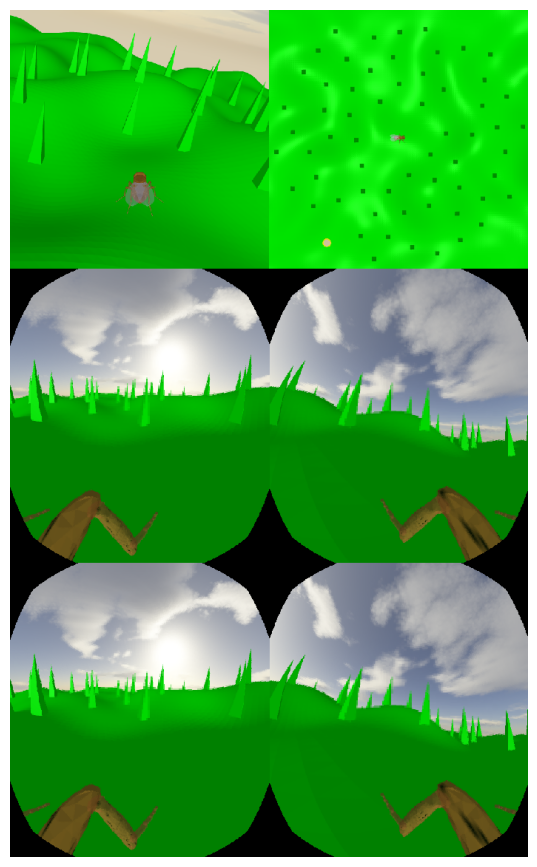

In [4]:
sim = MiniprojectSimulation(level=level, seed=seed)
controller = Controller(sim)

for _ in range(200):
    if manual_drive is None:
        joint_angles, adhesion = controller.step(sim)
    else:
        joint_angles, adhesion = controller.turning_controller.step(sim, manual_drive)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()

raw_vision = sim.get_raw_vision(sim.fly.name)
features, raw_panel, mask = extract_dragonfly_features(raw_vision)
world = get_world_frame(sim)
panel = make_debug_panel(world, raw_panel, mask)

print('step:', sim._curr_step)
for key, value in features.items():
    print(f'{key}: {value}')

plt.figure(figsize=(9, 11))
plt.imshow(panel)
plt.axis('off')
plt.show()

## Run A Trial And Log Features

Snapshots are saved when either red score or largest red blob size is high. This catches frames that a pure hue threshold might miss or misunderstand.

In [ ]:
sim = MiniprojectSimulation(level=level, seed=seed)
controller = Controller(sim)

records = []
snapshots = []
video_items = []

for _ in range(max_steps):
    if manual_drive is None:
        joint_angles, adhesion = controller.step(sim)
    else:
        joint_angles, adhesion = controller.turning_controller.step(sim, manual_drive)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()

    should_log = sim._curr_step % log_every == 0
    should_video = sim._curr_step % video_every == 0

    if should_log or should_video:
        raw_vision = sim.get_raw_vision(sim.fly.name)
        features, raw_panel, mask = extract_dragonfly_features(raw_vision)
        features['step'] = sim._curr_step

        if should_log:
            records.append(features.copy())

        suspicious = (
            features['red_score'] > 0.04
            or features['largest_blob_frac'] > 0.02
            or features['hsv_red_score'] > 0.04
        )
        if suspicious and len(snapshots) < snapshot_limit:
            world = get_world_frame(sim)
            panel = make_debug_panel(world, raw_panel, mask)
            snapshots.append((sim._curr_step, features.copy(), panel))

        if should_video:
            world = get_world_frame(sim)
            panel = make_debug_panel(world, raw_panel, mask)
            video_items.append((features.copy(), panel))

print('done')
print('samples:', len(records))
print('snapshots:', len(snapshots))
print('video frames:', len(video_items))

## Build Synchronized Video

This renders the saved vision panels together with the completed feature curves. The simulation has already run, so this is much faster to inspect than live plotting during rollout. The red dashed line marks the video frame's simulation step; purple lines mark saved suspicious snapshots.

In [ ]:
snapshot_steps = [step for step, _, _ in snapshots]

if len(video_items) == 0:
    raise RuntimeError('No video frames collected. Lower video_every or run the logging cell first.')

with imageio.get_writer(video_path, fps=12, codec='libx264') as writer:
    for features, panel in video_items:
        frame = make_video_frame(
            records=records,
            panel=panel,
            latest=features,
            snapshot_steps=snapshot_steps,
        )
        writer.append_data(frame)

print('wrote:', video_path)
display_looping_video(video_path)

## Feature Curves

Look for which cue rises first and cleanly: total red score, largest red blob, or temporal growth. The `looming` feature below is the positive derivative of the largest red blob size.

In [ ]:
steps = np.array([r['step'] for r in records])
red_scores = np.array([r['red_score'] for r in records])
dominance_scores = np.array([r['dominance_score'] for r in records])
hsv_scores = np.array([r['hsv_red_score'] for r in records])
left_scores = np.array([r['left_score'] for r in records])
right_scores = np.array([r['right_score'] for r in records])
side_bias = np.array([r['side_bias'] for r in records])
largest_blob = np.array([r['largest_blob_frac'] for r in records])
component_count = np.array([r['component_count'] for r in records])

looming = np.zeros_like(largest_blob)
if len(largest_blob) > 1:
    looming[1:] = np.maximum(0.0, np.diff(largest_blob))

fig, axs = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
axs[0].plot(steps, red_scores, label='combined red score')
axs[0].plot(steps, dominance_scores, label='RGB dominance score', alpha=0.8)
axs[0].plot(steps, hsv_scores, label='HSV red score', alpha=0.8)
axs[0].set_ylabel('fraction')
axs[0].legend()

axs[1].plot(steps, largest_blob, color='crimson', label='largest red blob')
axs[1].plot(steps, looming, color='black', label='positive blob growth / looming', alpha=0.8)
axs[1].set_ylabel('fraction')
axs[1].legend()

axs[2].plot(steps, left_scores, label='left eye')
axs[2].plot(steps, right_scores, label='right eye')
axs[2].set_ylabel('eye score')
axs[2].legend()

axs[3].plot(steps, side_bias, label='side bias')
axs[3].plot(steps, component_count, label='component count', alpha=0.5)
axs[3].set_xlabel('simulation step')
axs[3].legend()

apply_tufte(axs[0], steps, red_scores, dominance_scores, hsv_scores)
apply_tufte(axs[1], steps, largest_blob, looming)
apply_tufte(axs[2], steps, left_scores, right_scores)
apply_tufte(axs[3], steps, side_bias, component_count)

plt.show()

## Threshold Sweep

This compares simple red-score detection against a blob/looming-style detector. The blob detector may be more meaningful if hue alone fires on tiny or noisy pixels.

In [ ]:
def summarize_threshold(name, signal, thresholds):
    print(name)
    for thr in thresholds:
        active = signal > thr
        first = steps[np.argmax(active)] if np.any(active) else None
        print(
            f'  thr={thr:.6f} | active_samples={int(active.sum()):4d} '
            f'| active_fraction={active.mean():.4f} | first_step={first}'
        )

summarize_threshold('combined red score', red_scores, [0.001, 0.003, 0.005, 0.01, 0.02, 0.04, 0.06])
summarize_threshold('largest blob fraction', largest_blob, [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01])
summarize_threshold('looming / blob growth', looming, [0.00005, 0.0001, 0.0002, 0.0005, 0.001])

## Snapshot Timeline

Purple vertical lines mark every saved snapshot on the same curves. This is the quick check for whether the graph spike and the live/raw-vision frames are talking about the same event.

In [ ]:
plot_curves_with_snapshot_markers(records, snapshots)
print('snapshot steps:', [step for step, _, _ in snapshots])

## Suspicious Frames

Each panel shows: world camera, raw fly vision, red-mask overlay. Inspect whether detected red belongs to the dragonfly head, rendering artifacts, or something else.

In [ ]:
for step, features, panel in snapshots:
    title = (
        f"step={step} | red={features['red_score']:.5f} | "
        f"blob={features['largest_blob_frac']:.5f} | "
        f"side={features['side_bias']:.2f} | components={features['component_count']}"
    )
    plt.figure(figsize=(9, 11))
    plt.imshow(panel)
    plt.title(title)
    plt.axis('off')
    plt.show()

## Candidate Composite Detector

A useful next controller signal may combine color with shape and growth:

```python
attack_like = red_score > red_thr and largest_blob_frac > blob_thr
urgent = attack_like or looming > looming_thr
```

If `red_score` alone is noisy, prefer the composite detector. If `looming` rises too late, use the earliest reliable blob threshold instead.

In [ ]:
red_thr = 0.005
blob_thr = 0.001
looming_thr = 0.0002

attack_like = (red_scores > red_thr) & (largest_blob > blob_thr)
urgent_like = attack_like | (looming > looming_thr)

fig, ax = plt.subplots(figsize=(13, 4))
red_norm = red_scores / max(red_scores.max(), 1e-12)
blob_norm = largest_blob / max(largest_blob.max(), 1e-12)
looming_norm = looming / max(looming.max(), 1e-12)
ax.plot(steps, red_norm, label='red score normalized')
ax.plot(steps, blob_norm, label='largest blob normalized')
ax.plot(steps, looming_norm, label='looming normalized')
ax.fill_between(steps, 0, 1, where=attack_like, alpha=0.2, label='attack_like')
ax.fill_between(steps, 0, 1, where=urgent_like, alpha=0.15, label='urgent_like')
ax.set_xlabel('simulation step')
ax.legend()
apply_tufte(ax, steps, red_norm, blob_norm, looming_norm)
plt.show()

print('first attack_like step:', steps[np.argmax(attack_like)] if np.any(attack_like) else None)
print('first urgent_like step:', steps[np.argmax(urgent_like)] if np.any(urgent_like) else None)
print('attack_like samples:', int(attack_like.sum()))
print('urgent_like samples:', int(urgent_like.sum()))

## Report figures: level 4 dragonfly trial

The following cells generate report-ready plots from the rollout variables above. They convert simulation steps to seconds using `sim.timestep`, label axes with physical units, and save PNG files in `report_figures/`.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

report_dir = Path("report_figures")
report_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


def seconds_from_steps(steps):
    return np.asarray(steps, dtype=float) * sim.timestep


def seconds_for_history(history):
    return np.arange(len(history), dtype=float) * sim.timestep


def finish_report_figure(fig, filename):
    fig.tight_layout()
    out = report_dir / filename
    fig.savefig(out, bbox_inches="tight")
    print(f"saved {out}")
    return out


def require_records(records):
    if len(records) == 0:
        raise RuntimeError("Run the level-4 logging cell first so `records` is populated.")


def report_records_to_arrays(records):
    """Convert logged feature records to arrays used by the report figures."""
    require_records(records)

    def values(name, default=0.0):
        return np.array([r.get(name, default) for r in records], dtype=float)

    largest_blob = values("largest_blob_frac")
    looming = np.zeros_like(largest_blob)
    if len(largest_blob) > 1:
        looming[1:] = np.maximum(0.0, np.diff(largest_blob))

    return {
        "steps": values("step"),
        "red_scores": values("red_score"),
        "dominance_scores": values("dominance_score"),
        "hsv_scores": values("hsv_red_score"),
        "largest_blob": largest_blob,
        "looming": looming,
        "side_bias": values("side_bias"),
        "left_scores": values("left_score"),
        "right_scores": values("right_score"),
        "component_count": values("component_count"),
    }


In [ ]:
# Figure 1: dragonfly visual threat cues over real time.
require_records(records)
arrays = report_records_to_arrays(records)
time_s = seconds_from_steps(arrays["steps"])

fig, axs = plt.subplots(4, 1, figsize=(8.2, 8.8), sharex=True)

axs[0].plot(time_s, arrays["red_scores"], lw=1.8, label="combined red score")
axs[0].plot(time_s, arrays["hsv_scores"], lw=1.3, alpha=0.8, label="HSV red score")
axs[0].set_ylabel("red fraction")
axs[0].legend(loc="upper left", frameon=False)

axs[1].plot(time_s, arrays["largest_blob"], color="crimson", lw=1.8, label="largest red blob")
axs[1].plot(time_s, arrays["looming"], color="black", lw=1.3, alpha=0.8, label="positive blob growth")
axs[1].set_ylabel("image fraction")
axs[1].legend(loc="upper left", frameon=False)

axs[2].plot(time_s, arrays["left_scores"], lw=1.4, label="left eye")
axs[2].plot(time_s, arrays["right_scores"], lw=1.4, label="right eye")
axs[2].set_ylabel("red fraction")
axs[2].legend(loc="upper left", frameon=False)

axs[3].plot(time_s, arrays["side_bias"], color="tab:blue", lw=1.5)
axs[3].axhline(0.0, color="0.3", lw=0.8)
axs[3].set_ylabel("side bias")
axs[3].set_xlabel("time (s)")

for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

finish_report_figure(fig, "fig1_dragonfly_visual_threat_cues.png")
plt.show()

**Figure 1. Dragonfly visual threat cues during the level-4 trial.** Red-pixel scores quantify how much dragonfly-like red is visible in the fly's raw visual field. The largest-blob and looming traces distinguish a small distant cue from an expanding approaching cue. Left/right eye scores and side bias show whether the dragonfly is lateralized in the visual field. Time is reported in seconds.

In [ ]:
# Figure 2: commanded locomotor output from the integrated controller.
velocity_hist = np.asarray(controller.velocity_hist, dtype=float)
drive_hist = np.asarray(controller.drive_hist, dtype=float)

if len(velocity_hist) == 0 or len(drive_hist) == 0:
    raise RuntimeError("Run the controller rollout first so velocity_hist and drive_hist are populated.")

time_vel_s = seconds_for_history(velocity_hist)
time_drive_s = seconds_for_history(drive_hist)

fig, axs = plt.subplots(2, 1, figsize=(8.2, 5.8), sharex=True)

axs[0].plot(time_vel_s, velocity_hist[:, 0], lw=1.5, label="forward velocity")
axs[0].plot(time_vel_s, velocity_hist[:, 1], lw=1.5, label="turning velocity")
axs[0].axhline(0.0, color="0.3", lw=0.8)
axs[0].set_ylabel("target velocity\n(mm/s, rad/s)")
axs[0].legend(loc="upper left", frameon=False)

axs[1].plot(time_drive_s, drive_hist[:, 0], lw=1.4, label="left drive")
axs[1].plot(time_drive_s, drive_hist[:, 1], lw=1.4, label="right drive")
axs[1].axhline(0.0, color="0.3", lw=0.8)
axs[1].set_ylabel("descending drive")
axs[1].set_xlabel("time (s)")
axs[1].legend(loc="upper left", frameon=False)

for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

finish_report_figure(fig, "fig2_controller_outputs.png")
plt.show()

**Figure 2. Controller outputs during the level-4 trial.** The top panel shows the velocity vector requested by the high-level controller before conversion through the inverse model. Positive forward velocity drives walking, while the turning velocity controls yaw. The lower panel shows the left and right descending drives sent to the CPG controller after inverse-model conversion. Time is reported in seconds.

In [ ]:
# Figure 3: behavior-relevant sensory components and final controller command.
velocity_hist = np.asarray(controller.velocity_hist, dtype=float)
olfaction_hist = np.asarray(controller.olfaction.velocity_hist, dtype=float)
vision_hist = np.asarray(controller.vision.velocity_hist, dtype=float)

time_vel_s = seconds_for_history(velocity_hist)
time_odor_s = seconds_for_history(olfaction_hist)

fig, axs = plt.subplots(3, 1, figsize=(8.2, 7.6), sharex=False)

axs[0].plot(time_odor_s, olfaction_hist[:, 0], lw=1.5, label="odor forward")
axs[0].plot(time_odor_s, olfaction_hist[:, 1], lw=1.5, label="odor turn")
axs[0].set_ylabel("odor velocity\n(mm/s, rad/s)")
axs[0].legend(loc="upper left", frameon=False)

if len(vision_hist) > 0:
    # Vision obstacle history only updates when obstacle vision is evaluated.
    time_vision_s = np.arange(len(vision_hist), dtype=float) * log_every * sim.timestep
    axs[1].plot(time_vision_s, vision_hist[:, 0], lw=1.5, label="obstacle forward correction")
    axs[1].plot(time_vision_s, vision_hist[:, 1], lw=1.5, label="obstacle turn correction")
else:
    axs[1].text(0.5, 0.5, "No obstacle-vision samples recorded", ha="center", va="center", transform=axs[1].transAxes)
axs[1].axhline(0.0, color="0.3", lw=0.8)
axs[1].set_ylabel("obstacle velocity\n(mm/s, rad/s)")
axs[1].legend(loc="upper left", frameon=False)

axs[2].plot(time_vel_s, velocity_hist[:, 0], lw=1.5, label="final forward command")
axs[2].plot(time_vel_s, velocity_hist[:, 1], lw=1.5, label="final turn command")
axs[2].axhline(0.0, color="0.3", lw=0.8)
axs[2].set_ylabel("final velocity\n(mm/s, rad/s)")
axs[2].set_xlabel("time (s)")
axs[2].legend(loc="upper left", frameon=False)

for ax in axs:
    ax.grid(True, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

finish_report_figure(fig, "fig3_sensory_to_motor_components.png")
plt.show()

**Figure 3. Sensory components contributing to the final motor command.** Odor tracking provides the baseline forward and turning command, obstacle vision contributes braking and steering corrections when evaluated, and the integrated controller combines these with wind and dragonfly-state logic into the final target velocity. The obstacle-vision trace is sampled only when obstacle processing runs, so it is shown on its own time axis converted to seconds.

In [ ]:
# Figure 4: saved visual snapshots near suspicious dragonfly detections.
if len(snapshots) == 0:
    print("No snapshots were saved. Increase `snapshot_limit` or lower the suspicious thresholds in the logging cell.")
else:
    n_show = min(6, len(snapshots))
    fig, axs = plt.subplots(1, n_show, figsize=(3.2 * n_show, 4.4))
    if n_show == 1:
        axs = [axs]

    for ax, (step, features, panel) in zip(axs, snapshots[:n_show]):
        ax.imshow(panel)
        ax.set_title(
            f"t={step * sim.timestep:.2f} s\n"
            f"red={features['red_score']:.3f}, blob={features['largest_blob_frac']:.3f}",
            fontsize=10,
        )
        ax.axis("off")

    finish_report_figure(fig, "fig4_dragonfly_snapshot_panels.png")
    plt.show()

**Figure 4. Representative visual snapshots from the level-4 dragonfly trial.** Each panel contains the world camera, the fly's raw visual input, and the red-mask overlay used by the detector. The titles report the corresponding simulation time in seconds, red score, and largest red-blob fraction. These panels help verify that spikes in Figure 1 correspond to the dragonfly rather than rendering artifacts.

In [ ]:
# Report text helper: mention generated video and saved figures.
print("Generated report figures:")
for png in sorted(report_dir.glob("fig*.png")):
    print(" -", png)

if Path(video_path).exists():
    print(f"\nVideo to mention in the report: {video_path}")
else:
    print("\nNo video file found yet. Run the video export cell if you want to provide a movie.")